<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 11 </b></center>
<center><b><h5>K-means, K-Medoids</b></center>
<pre>    

# Step 1: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Step 2: Load the Dataset
Load Given dataset -  StudentsPerformance.csv

In [2]:
df=pd.read_csv("StudentsPerformance.csv")

In [6]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# Step 3: Data Overview
In this step, we examine the dataset structure, summary statistics, and check for missing values.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [8]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [9]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

# Step 4: Display PairPlot

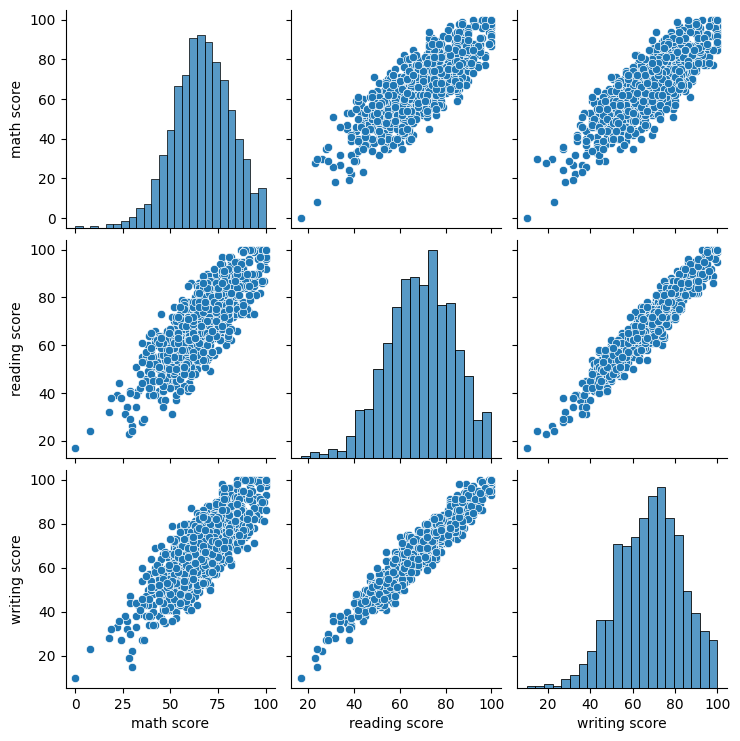

In [ ]:
sns.pairplot(df) 

# Step 6: Distribution of numerical features

In [11]:
numeric_df=df[['math score','reading score','writing score']]
numeric_df.head()

,math score,reading score,writing score
0,72,72,74
1,69,90,88
2,90,95,93
3,47,57,44
4,76,78,75


In [14]:
numeric_df.corr()

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


# Correlation heatmap

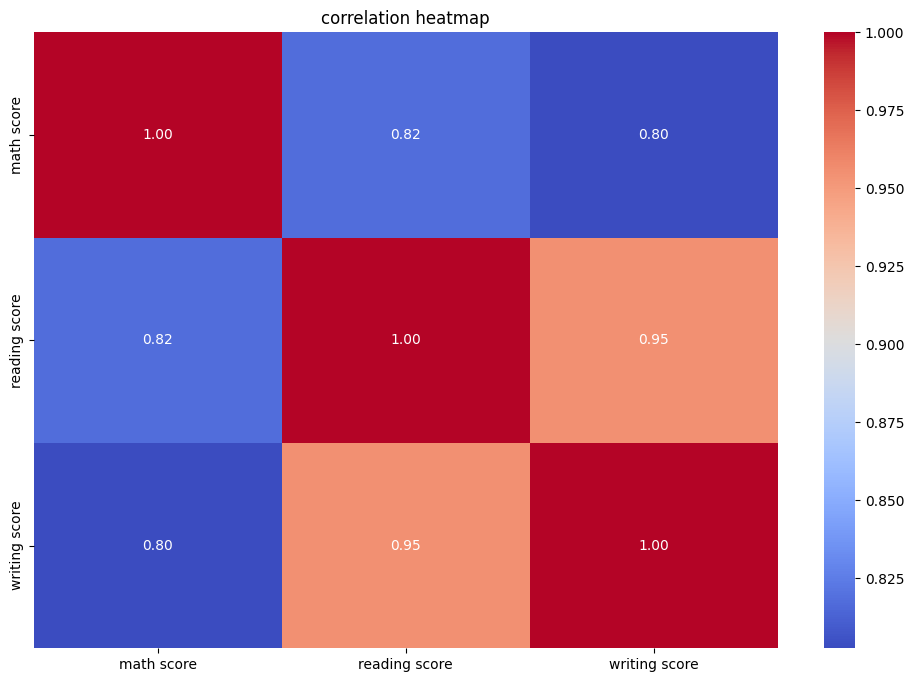

In [13]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("correlation heatmap")
plt.show()

# Step 7: Apply StandardScaler

In [16]:
X=numeric_df

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)
print(X_scaled[:5])




[[ 0.39002351  0.19399858  0.39149181]
 [ 0.19207553  1.42747598  1.31326868]
 [ 1.57771141  1.77010859  1.64247471]
 [-1.25954302 -0.83389925 -1.58374436]
 [ 0.65395415  0.60515772  0.45733301]]


# Step 8: Elbow method to find optimal k

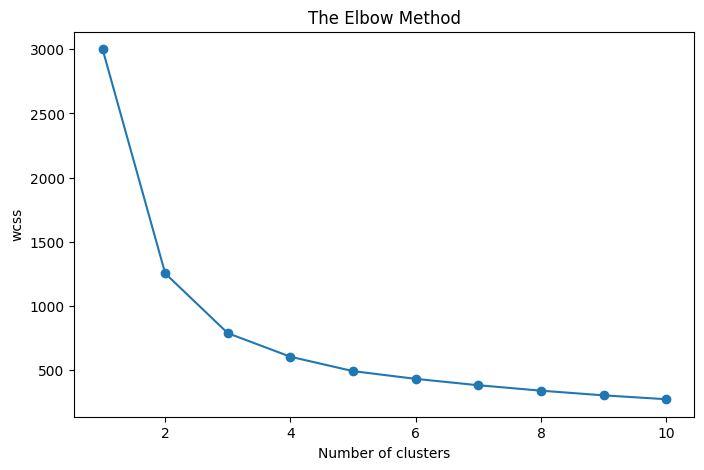

In [ ]:
wcss=[]

for i in range(1,11):
    kmeans=KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

    
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('wcss')
plt.show()


# Step 9:Based on the elbow plot, choose an appropriate k value (e.g., k=3)

In [23]:
kmeans=KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters=kmeans.fit_predict(X_scaled)

df['Cluster']=clusters
df[['math score','reading score','writing score','Cluster']].head()

,math score,reading score,writing score,Cluster
0,72,72,74,0
1,69,90,88,2
2,90,95,93,2
3,47,57,44,1
4,76,78,75,2


# Step 10: Print Cluster Center

# Step 11: Plot Cluster

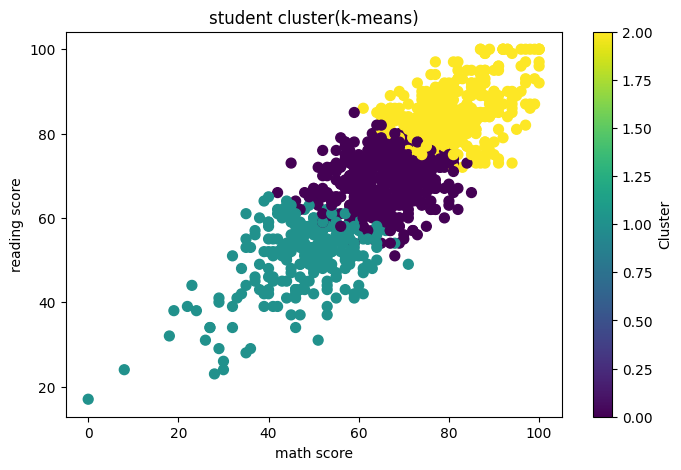

In [26]:
plt.figure(figsize=(8,5))
plt.scatter(
    df['math score'],
    df['reading score'],
    c=df['Cluster'],
    cmap='viridis',
    s=50
)

plt.xlabel("math score")
plt.ylabel("reading score")
plt.title("student cluster(k-means)")
plt.colorbar(label="Cluster")

plt.show()

# Step 12:Analyze clusters 

# Step 13: Perform K-Medoids

# Step:14 Comparison of K-means and K-medoids Clusters

# Step: 15 | USE KMEAN++
